# Multiclass Classification
using Neural Network

MNIST 데이터셋 사용

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import random
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

import tensorflow as tf
import keras
keras.utils.set_random_seed(SEED)

## 데이터 준비

In [2]:
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [3]:
x_train.shape, y_train.shape, x_test.shape, y_test.shape

((60000, 28, 28), (60000,), (10000, 28, 28), (10000,))

### EDA

#### 랜덤 확인

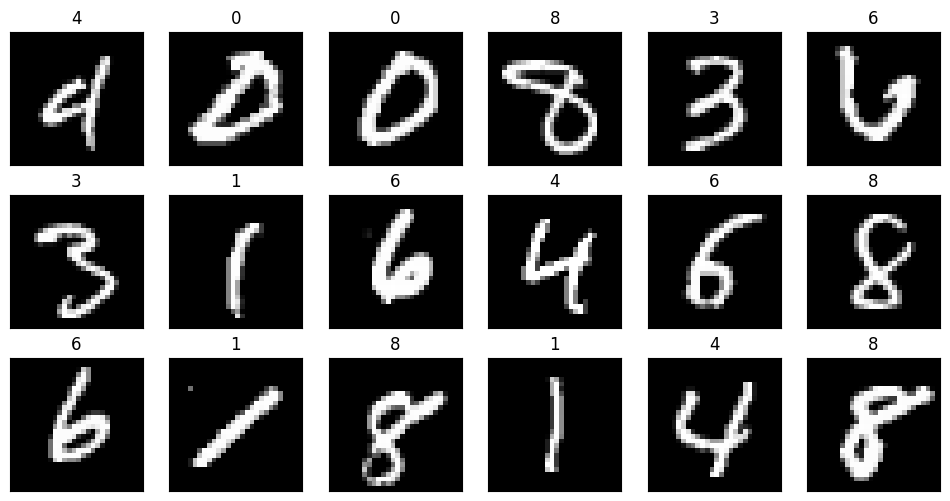

In [4]:
samples = np.random.randint(len(x_train), size=18)

plt.figure(figsize = (12, 6))
for i, idx in enumerate(samples):
    plt.subplot(3, 6, i+1)
    plt.xticks([])
    plt.yticks([])
    plt.imshow(x_train[idx], cmap = 'gray')
    plt.title(y_train[idx].item())
plt.show()

### 데이터 분리

위에서 이미 train과 test를 따로 불러왔으니까,

train을 다시 validation과 train으로 분리

In [6]:
from sklearn.model_selection import train_test_split

x_train, x_val, y_train, y_val = train_test_split(x_train, y_train,
                                  test_size = 0.2, random_state = SEED, shuffle=True)

In [7]:
x_train.shape, x_val.shape, y_train.shape, y_val.shape

((48000, 28, 28), (12000, 28, 28), (48000,), (12000,))

## 전처리

### Scaling (Min Max)

x만

In [8]:
x_train_s = x_train / 255.
x_val_s = x_val / 255.

### Encoding (One Hot)

y만

In [9]:
from keras.utils import to_categorical

y_train_e = to_categorical(y_train, num_classes=10)
y_val_e = to_categorical(y_val, num_classes=10)

### 이미지 1장을 2차원 행렬에서 1차원 벡터로 펴기

In [10]:
x_train_s = x_train_s.reshape(-1, 28*28)
x_val_s = x_val_s.reshape(-1, 28*28)

## 모델 정의

x_train_s = (48000, 28) 이었음

In [11]:
from keras import layers
model = keras.Sequential([
    keras.Input(shape=(784,)),
    layers.Dense(32, activation='relu'),
    layers.Dense(16, activation='relu'),
    layers.Dense(10, activation='softmax')
])

In [12]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │        25,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           170 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 25,818 (100.85 KB)

 Trainable params: 25,818 (100.85 KB)

 Non-trainable params: 0 (0.00 B)

## 컴파일

In [14]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

## 학습

In [17]:
EPOCHS = 30

history = model.fit(
    x_train_s, y_train_e,
    epochs = EPOCHS,
    batch_size = 256,
    validation_data = (x_val_s, y_val_e)
)

Epoch 1/30
188/188 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.9396 - loss: 0.2094 - val_accuracy: 0.9405 - val_loss: 0.2104
Epoch 2/30
188/188 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9429 - loss: 0.1980 - val_accuracy: 0.9423 - val_loss: 0.2034
Epoch 3/30
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9450 - loss: 0.1907 - val_accuracy: 0.9443 - val_loss: 0.1975
Epoch 4/30
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9467 - loss: 0.1839 - val_accuracy: 0.9455 - val_loss: 0.1920
Epoch 5/30
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9486 - loss: 0.1774 - val_accuracy: 0.9465 - val_loss: 0.1868
Epoch 6/30
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9504 - loss: 0.1710 - val_accuracy: 0.9469 - val_loss: 0.1817
Epoch 7/30
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9520 - loss: 0.1647 - val_accuracy: 0.9479 - val_loss: 0.1767
Epoch 8/30
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9538 - loss: 0.1584 - val_accuracy: 0

### 학습 결과 그래프

In [18]:
def plot_history(history):
  hist = pd.DataFrame(history.history)
  hist['epoch'] = history.epoch

  plt.figure(figsize=(16,8))

  plt.subplot(1,2,1)
  plt.xlabel('Epoch')
  plt.ylabel('Loss')
  plt.plot(hist['epoch'], hist['loss'], label='Train Loss')
  plt.plot(hist['epoch'], hist['val_loss'], label = 'Val Loss')
  plt.legend()

  plt.subplot(1,2,2)
  plt.xlabel('Epoch')
  plt.ylabel('Accuracy')
  plt.plot(hist['epoch'], hist['accuracy'], label='Train Accuracy')
  plt.plot(hist['epoch'], hist['val_accuracy'], label = 'Val Accuracy')

  plt.legend()
  plt.show()

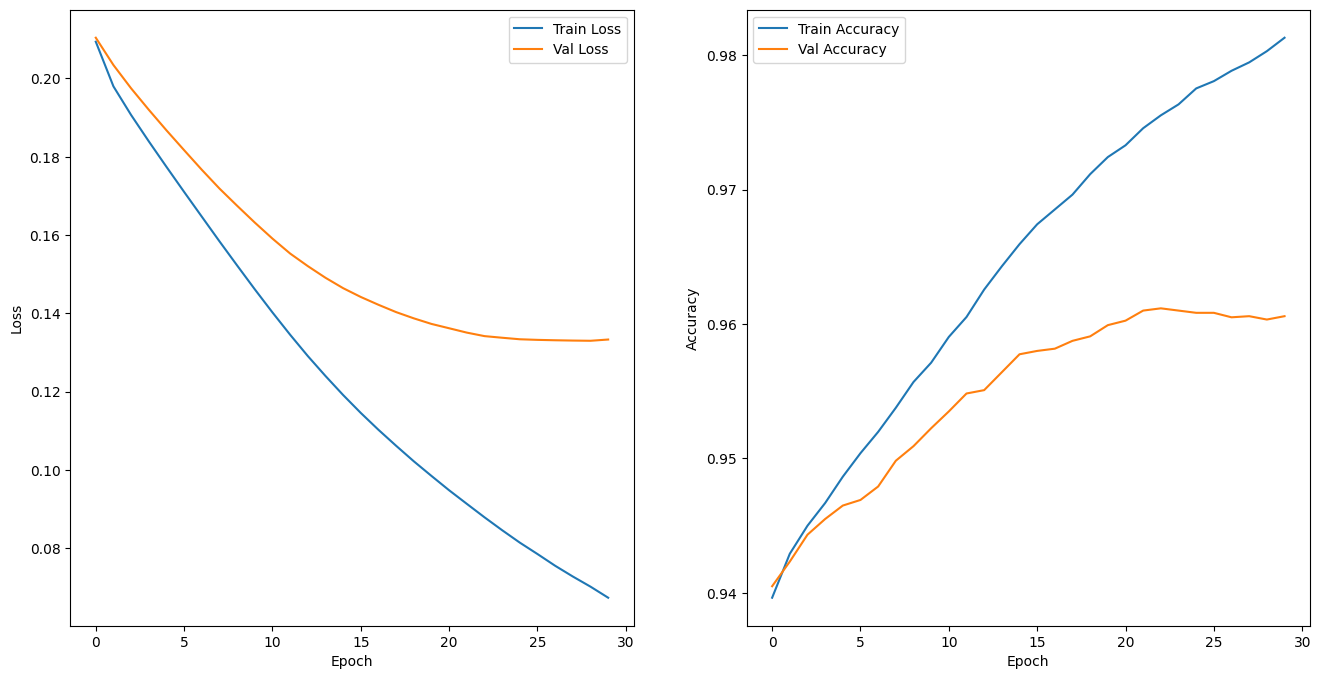

In [19]:
plot_history(history)

## 테스트

### x scaling만 하고, y encoding은 생략

In [20]:
x_test_s = x_test / 255.
x_test_s = x_test / 255.

In [21]:
x_test_s = x_test_s.reshape(-1, 28*28)
x_test_s = x_test_s.reshape(-1, 28*28)

### 돌려보기

In [22]:
y_pred = model.predict(x_test_s)
y_pred[:10]

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step


array([[1.22705171e-06, 7.76298137e-08, 2.99777676e-05, 1.05375424e-03,
        1.25781230e-09, 3.03890720e-05, 1.59487712e-13, 9.98336971e-01,
        3.07506161e-06, 5.44652808e-04],
       [2.40036388e-06, 4.67261067e-04, 9.99523818e-01, 2.06517188e-06,
        3.41647283e-13, 1.96403121e-07, 4.47863755e-07, 3.42636415e-14,
        3.66949803e-06, 2.20382328e-12],
       [5.11334747e-07, 9.99099135e-01, 9.68579843e-05, 8.97719985e-07,
        2.08357742e-05, 1.14743299e-04, 4.32881461e-06, 6.29804563e-04,
        3.19706960e-05, 1.03088951e-06],
       [9.99820471e-01, 2.08331041e-09, 1.01096455e-04, 5.81890054e-05,
        5.04872544e-09, 2.04674436e-07, 7.06011679e-06, 9.38688117e-07,
        4.45475585e-08, 1.19689475e-05],
       [2.96789676e-06, 1.92933541e-07, 1.14856425e-06, 1.29898950e-07,
        9.84366179e-01, 2.92937511e-06, 2.77616527e-06, 2.25386284e-05,
        1.81009036e-05, 1.55830989e-02],
       [5.96769212e-08, 9.98615086e-01, 2.39145993e-06, 2.34194502e-07,
   

각 리스트 안에서 확률값이 가장 높은 애의 인덱스가 정답.

7, 2, 1, 0, ....

In [23]:
y_pred = np.argmax(y_pred, axis=1)
y_pred[:10]

array([7, 2, 1, 0, 4, 1, 4, 9, 6, 9])

## 결과확인

In [24]:
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score
from sklearn.metrics import confusion_matrix

def print_metrics(y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)    # 맞힌 개수 / 전체 개수
    print(f"1. Accuracy: {acc:.4f}")

    re = recall_score(y_true, y_pred, average='macro')     # TP / (TP + FN)
    print(f"2. Recall: {re:.4f}")

    pr = precision_score(y_true, y_pred, average='macro')    # TP / (TP + FP)
    print(f"3. Precision: {pr:.4f}")

    f1 = f1_score(y_true, y_pred, average='macro')       # (2 * Precision * Recall) / (Precision + Recall)
    print(f"4. F1 Score: {f1:.4f}")

    # (정답, 예측값) 순서대로 지정한다!!!
    cfm = confusion_matrix(y_true, y_pred)
    s = sns.heatmap(cfm, annot=True, cmap='Blues', fmt='d', cbar=False)
    s.set(xlabel='Prediction', ylabel='Actual')
    plt.show()

1. Accuracy: 0.9614
2. Recall: 0.9611
3. Precision: 0.9612
4. F1 Score: 0.9611


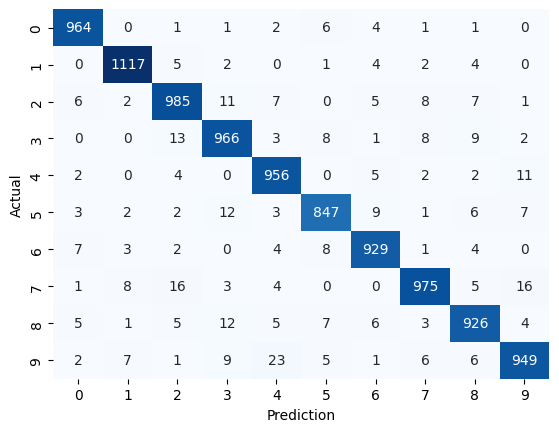

In [25]:
print_metrics(y_test, y_pred)